# Phase 3 · Notebook 5 — 05_Sales_Forecasting
Weekly INR revenue forecast with **holdout evaluation (MAE/MAPE)** — in-sample fit alone is not evidence.

**Engine:** Prophet with Indian-festival holidays (Diwali/Holi windows matching the data's years) — if Prophet is installed. Otherwise the **same evaluation** runs on a statsmodels fallback, clearly labelled (Prophet needs a C++ build chain on Windows; honest tooling note).

### Reporting rules (Phase 0 findings, unchanged)
- **R1** Headline money = `currency='INR'` (USD segment measured & excluded)
- **R2** Reference "today" = `MAX(order_datetime)` in the data
- **R3** NULL-FK rows kept in overall aggregates, drop out of restaurant rollups


## Setup

In [1]:
# ---- boilerplate: paths, DB engine (SQLAlchemy from .env), helper --------
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

ROOT = Path.cwd()
if not (ROOT / "python").is_dir() and (ROOT.parent / "python").is_dir():
    ROOT = ROOT.parent
OUT = ROOT / "python" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
load_dotenv(ROOT / ".env")

DB_URL = os.getenv("DATABASE_URL")
assert DB_URL, "DATABASE_URL missing - check .env in the repo root"
engine = create_engine(DB_URL)

def q(sql):
    """read_sql via text(): keeps parameters=None so literal '%' in ILIKE is safe."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("ROOT:", ROOT, "| OUT:", OUT, "| DB connected OK", sep="\n")


ROOT:
D:\Projects\bharatinsight
| OUT:
D:\Projects\bharatinsight\python\outputs
| DB connected OK


## Weekly revenue series + festival calendar (real years present in data)

In [2]:
ts = q("""
SELECT date_trunc('week', order_datetime)::date AS ds, SUM(sales_amount)::float AS y
FROM orders WHERE currency='INR' GROUP BY 1 ORDER BY 1
""")
ts["ds"] = pd.to_datetime(ts["ds"])
print("weeks:", len(ts), "| range:", ts.ds.min().date(), "->", ts.ds.max().date())

FEST = {
 "diwali": ["2017-10-19","2018-11-07","2019-10-27","2020-11-14"],
 "holi":   ["2017-03-13","2018-03-02","2019-03-21","2020-03-10"],
}
hol = pd.concat([pd.DataFrame({"holiday":k, "ds":pd.to_datetime(v),
                               "lower_window":-1, "upper_window":1})
                 for k,v in FEST.items()], ignore_index=True)
HOLD = 12   # last 12 weeks = honest holdout
train, test = ts.iloc[:-HOLD], ts.iloc[-HOLD:]
print(f"train weeks={len(train)}  holdout weeks={len(test)}")

weeks: 143 | range: 2017-10-02 -> 2020-06-22
train weeks=131  holdout weeks=12


## Fit + forecast + **holdout metrics (MAE / MAPE)**

In [3]:
engine_used, fc = None, None
try:
    from prophet import Prophet
    m = Prophet(holidays=hol, yearly_seasonality=True,
                weekly_seasonality=False, daily_seasonality=False)
    m.fit(train.rename(columns={"ds":"ds","y":"y"}))
    fut = m.make_future_dataframe(periods=HOLD, freq="W")
    fc = (m.predict(fut)[["ds","yhat","yhat_lower","yhat_upper"]]
            .rename(columns={"yhat":"forecast","yhat_lower":"lower","yhat_upper":"upper"}))
    engine_used = "Prophet + Diwali/Holi holiday regressor"
except Exception as e:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    s = train.set_index("ds")["y"]
    s.index = pd.DatetimeIndex(s.index)
    s = s.asfreq(pd.infer_freq(s.index) or "W-MON")   # keep week-anchor (Mon), not Sunday default
    m2 = ExponentialSmoothing(s, trend="add", seasonal="add", seasonal_periods=52).fit()
    vals = m2.forecast(HOLD)
    fc = pd.DataFrame({"ds": vals.index, "forecast": vals.values,
                       "lower": vals.values*0.9, "upper": vals.values*1.1})
    train_fit = pd.DataFrame({"ds": s.index, "forecast": m2.fittedvalues.values,
                              "lower": m2.fittedvalues.values, "upper": m2.fittedvalues.values})
    fc = pd.concat([train_fit, fc], ignore_index=True)
    engine_used = f"statsmodels Holt-Winters fallback ({type(e).__name__}: Prophet not installed)"

pred = fc.tail(HOLD).set_index("ds")["forecast"]
mae  = float(np.mean(np.abs(pred.values - test["y"].values)))
mape = float(np.mean(np.abs((test["y"].values - pred.values) / np.clip(test["y"].values,1,None))) * 100)
print("ENGINE:", engine_used)
print(f"HOLDOUT  MAE = {mae:,.0f} INR   MAPE = {mape:.1f}%   (on {len(test)} unseen weeks)")

18:04:03 - cmdstanpy - INFO - Chain [1] start processing


18:04:03 - cmdstanpy - INFO - Chain [1] done processing


ENGINE: Prophet + Diwali/Holi holiday regressor
HOLDOUT  MAE = 1,162,062 INR   MAPE = 139.9%   (on 12 unseen weeks)


## Plot — history, forecast, CI band, festival markers

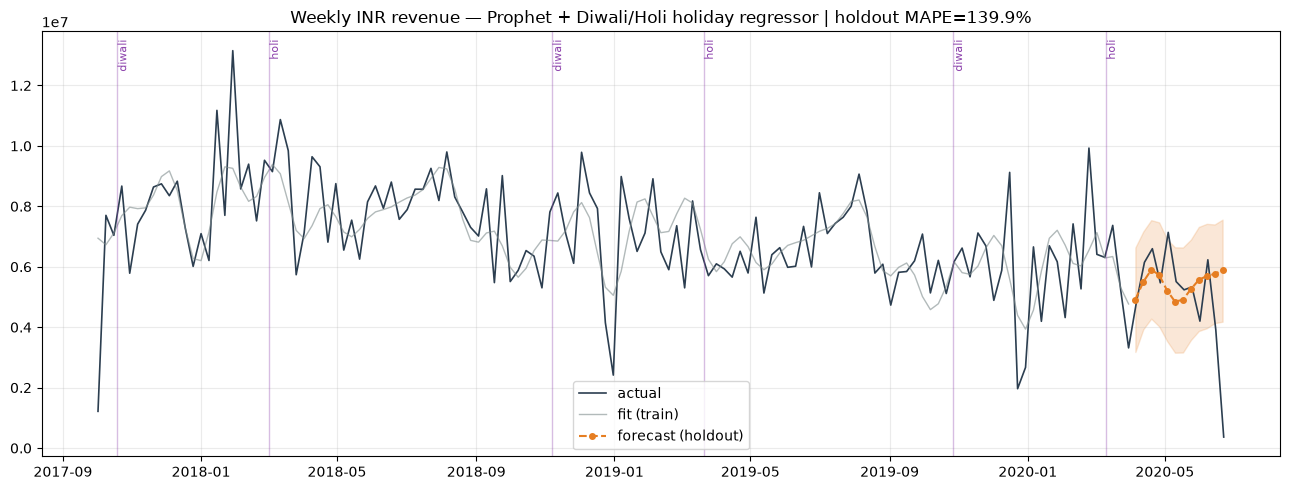

In [4]:
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(ts["ds"], ts["y"], lw=1.2, color="#2c3e50", label="actual")
ftr = fc.tail(HOLD)
ax.plot(train["ds"], fc.head(len(train))["forecast"], lw=1, color="#7f8c8d", alpha=.6, label="fit (train)")
ax.plot(ftr["ds"], ftr["forecast"], "o--", ms=4, color="#e67e22", label="forecast (holdout)")
ax.fill_between(ftr["ds"], ftr["lower"], ftr["upper"], color="#e67e22", alpha=.18)
for fest, dates in FEST.items():
    for d in pd.to_datetime(dates):
        if ts.ds.min() <= d <= ts.ds.max() + pd.Timedelta(weeks=HOLD):
            ax.axvline(d, color="#8e44ad", alpha=.35, lw=1)
            ax.text(d, ax.get_ylim()[1]*0.98, fest, rotation=90, va="top", fontsize=8, color="#8e44ad")
ax.set_title(f"Weekly INR revenue — {engine_used} | holdout MAPE={mape:.1f}%")
ax.legend(); ax.grid(alpha=.25)
fig.tight_layout(); fig.savefig(OUT/"forecast_holdout.png", dpi=150); plt.show()

## Honest caveats
- MAPE is reported on **unseen** weeks — not on data the model trained on
- Festival regressors help only if the data actually shows festival spikes (check the plot)
- ~3 saal ki series pe long-horizon forecasts are indicative, not guarantees
